# What is Pooling in CNN
Pooling is a downsampling operation used in Convolutional Neural Networks (CNNs).

It reduces the spatial size of feature maps.
It keeps the most important information while discarding redundant details.
It helps make the network more translation-invariant and reduces computation.


# Common types
<h4>Max pooling:</h4>
  selects the maximum value in each region.
<h4>Average pooling:</h4>
 computes the average value in each region.


# Why it matters
Reduces number of parameters and computation.
Helps prevent overfitting.
Makes features more robust to small shifts and distortions.


Example
If you apply 2x2 max pooling on a feature map, each non-overlapping 2x2 block is replaced by its maximum value, producing a smaller output map.

# Detail pratical Exmple on Mnist Dataset

In [1]:
from keras.datasets import mnist
from keras.models import  Sequential
from keras.layers import Dense, Dropout, Flatten,Conv2D, MaxPooling2D
from sklearn.metrics import accuracy_score
from keras.callbacks import EarlyStopping

In [2]:
(X_train,y_train),(X_test,y_test)=mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
X_train=X_train/255
X_test=X_test/255


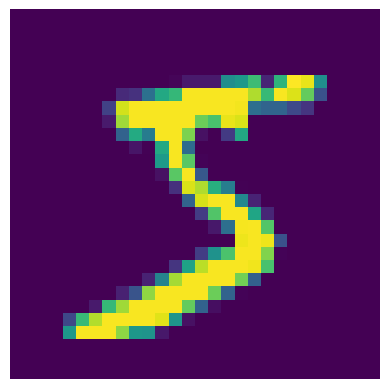

In [4]:
import matplotlib.pyplot as plt
plt.imshow(X_train[0])
plt.axis('off')
plt.show()



> Model with MaxPooling



In [5]:
model=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [7]:
model.fit(X_train,y_train,batch_size=100,epochs=100,callbacks=EarlyStopping(patience=3),validation_split=0.2)

Epoch 1/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8344 - loss: 0.5705 - val_accuracy: 0.9723 - val_loss: 0.0917
Epoch 2/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9769 - loss: 0.0766 - val_accuracy: 0.9823 - val_loss: 0.0662
Epoch 3/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9844 - loss: 0.0510 - val_accuracy: 0.9852 - val_loss: 0.0496
Epoch 4/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9871 - loss: 0.0412 - val_accuracy: 0.9852 - val_loss: 0.0512
Epoch 5/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9904 - loss: 0.0317 - val_accuracy: 0.9862 - val_loss: 0.0482
Epoch 6/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9930 - loss: 0.0230 - val_accuracy: 0.9884 - val_loss: 0.0418
Epoch 7/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.9854 - val_loss: 0.0517
Epoch 8/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9954 - loss: 0.0162 - val_accu

In [8]:
y_prd=model.predict(X_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [9]:
accuracy_score(y_test,y_prd.argmax(axis=1))

0.9877



> AveragePooling



In [20]:
from keras.layers import AveragePooling2D

In [13]:
model2=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    AveragePooling2D((2,2)),
    Conv2D(64,(3,3),activation='relu'),
    AveragePooling2D((2,2)),
    Flatten(),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model2.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
model2.fit(X_train,y_train,batch_size=100,epochs=100,callbacks=EarlyStopping(patience=3),validation_split=0.2)


Epoch 1/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - accuracy: 0.8131 - loss: 0.6439 - val_accuracy: 0.9704 - val_loss: 0.1057
Epoch 2/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9698 - loss: 0.1014 - val_accuracy: 0.9759 - val_loss: 0.0821
Epoch 3/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9796 - loss: 0.0641 - val_accuracy: 0.9827 - val_loss: 0.0586
Epoch 4/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9828 - loss: 0.0557 - val_accuracy: 0.9846 - val_loss: 0.0551
Epoch 5/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9864 - loss: 0.0426 - val_accuracy: 0.9831 - val_loss: 0.0535
Epoch 6/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9882 - loss: 0.0366 - val_accuracy: 0.9833 - val_loss: 0.0575
Epoch 7/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9907 - loss: 0.0298 - val_accuracy: 0.9886 - val_loss: 0.0394
Epoch 8/100
480/480 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9916 - loss: 0.0267 - val_accu

In [16]:
y_pred=model2.predict(X_test)
y_pred=y_pred.argmax(axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [17]:
accuracy_score(y_test,y_pred)


0.9881